lets import the data first and see how it goes.

In [1]:
import pandas as pd
  
# makes the passed rows header
data = pd.read_csv("laplace.csv", header =[0])

In [2]:
data

,x,y,u
0,0.00,0.0,0.00
1,0.01,0.0,0.01
2,0.02,0.0,0.02
3,0.03,0.0,0.03
4,0.04,0.0,0.04
...,...,...,...
10196,0.96,1.0,0.96
10197,0.97,1.0,0.97
10198,0.98,1.0,0.98
10199,0.99,1.0,0.99


In [3]:
import numpy as np
converted = np.array(data)

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(converted[:,0:2], converted[:,2], test_size=0.33, random_state=42)

OK, The first section would be a surrogate model, Next Section would be a PINN method

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
# Keras :
from keras import backend as K
import tensorflow as tf
import keras 
from keras.layers import Input, Dense, add, Activation, Reshape , Conv1D, Flatten ,GlobalAveragePooling1D , Lambda, Dropout, concatenate
from keras.models import Model, model_from_json, model_from_yaml
from keras import optimizers 
from keras.callbacks import CSVLogger
from keras.losses import mse
from keras.utils.generic_utils import get_custom_objects

In [7]:

class EarlyStoppingAtMinLoss(tf.keras.callbacks.Callback):
  """Stop training when the loss is at its min, i.e. the loss stops decreasing.

  Arguments:
      patience: Number of epochs to wait after min has been hit. After this
      number of no improvement, training stops.
  """

  def __init__(self, patience=20):
    super(EarlyStoppingAtMinLoss, self).__init__()

    self.patience = patience

    # best_weights to store the weights at which the minimum loss occurs.
    self.best_weights = None

  def on_train_begin(self, logs=None):
    # The number of epoch it has waited when loss is no longer minimum.
    self.wait = 0
    # The epoch the training stops at.
    self.stopped_epoch = 0
    # Initialize the best as infinity.
    self.best = np.Inf

  def on_epoch_end(self, epoch, logs=None):
    current = logs.get('loss')
    if np.less(current, self.best):
      self.best = current
      self.wait = 0
      # Record the best weights if current results is better (less).
      self.best_weights = self.model.get_weights()
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.stopped_epoch = epoch
        self.model.stop_training = True
        print('Restoring model weights from the end of the best epoch.')
        self.model.set_weights(self.best_weights)

  def on_train_end(self, logs=None):
    if self.stopped_epoch > 0:
      print('Epoch %05d: early stopping' % (self.stopped_epoch + 1))

In [33]:
input1 = keras.layers.Input(shape=(1, ))
input2 = keras.layers.Input(shape=(1,))
merged = keras.layers.Concatenate(axis=1)([input1, input2])
dense1 = keras.layers.Dense(50, input_dim=2, activation=keras.activations.relu, use_bias=False)(merged)
dense2 = keras.layers.Dense(50, input_dim=2, activation=keras.activations.relu, use_bias=False)(dense1)
output = keras.layers.Dense(1, activation=keras.activations.relu, use_bias=True)(add([dense1, dense2]))
model2 = keras.models.Model(inputs=[input1, input2], outputs=output)

In [34]:
# Setting the optimizer parameters
opt = optimizers.Nadam(lr=0.05, beta_1=0.9, beta_2=0.999)

In [37]:
model2.compile(optimizer=opt,
             loss='mse',
             metrics=['mae']
             )

In [38]:
history2 = model2.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.05, epochs=50, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/50
130/130 [==============================] - 7s 29ms/step - loss: 0.3352 - mae: 0.5005 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 2/50
130/130 [==============================] - 3s 22ms/step - loss: 0.3343 - mae: 0.4997 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 3/50
130/130 [==============================] - 3s 23ms/step - loss: 0.3355 - mae: 0.5008 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 4/50
130/130 [==============================] - 3s 23ms/step - loss: 0.3308 - mae: 0.4956 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 5/50
130/130 [==============================] - 3s 22ms/step - loss: 0.3384 - mae: 0.5036 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 6/50
130/130 [==============================] - 3s 25ms/step - loss: 0.3389 - mae: 0.5057 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 7/50
130/130 [==============================] - 3s 24ms/step - loss: 0.3359 - mae: 0.5020 - val_loss: 0.3435 - val_mae: 0.5091
Epoch 8/50
130/130 [==============================] - 4s 27ms/step - 

In [39]:
loss,MAE = model2.evaluate([X_test[:,0],X_test[:,0]], y_test)

106/106 [==============================] - 2s 19ms/step - loss: 0.3305 - mae: 0.4953: 0s - loss: 0.3290 - mae: 0.


In [40]:
predicted_u = model2.predict([X_test[:,0],X_test[:,0]],batch_size=150)
print('mean of prediction : %.8f' % (np.mean(predicted_u)))
print('norm of the mean of the commited error : %.8f' % (np.linalg.norm(np.mean(predicted_u) - np.mean(y_test))))

mean of prediction : 0.00000000
norm of the mean of the commited error : 0.49532522


In [41]:
err =[]
for i in range(len(predicted_u)):
    err.append(predicted_u[i]-y_test[i])
err = np.array(err)
print('mean of L2 commited error: %.8f'%(np.linalg.norm(err)))

mean of L2 commited error: 33.35853958


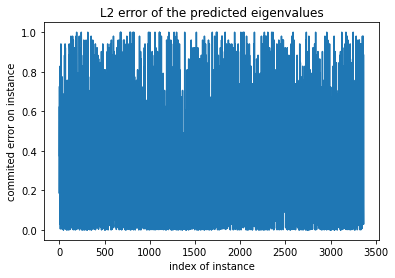

In [42]:
L2_Errors = []
for i in range(predicted_u.shape[0]):
    L2_Errors.append((y_test[i] - predicted_u[i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

In [43]:
T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

Percentage of the commited error between 0,5e-6 is: 0.83160083
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 1.98990199
Percentage of the commited error between 5e-4,5e-3 is: 6.08850609
Percentage of the commited error between 5e-3,5e-2 is: 13.98871399
Percentage of the commited error between 5e-2,5e-1 is: 48.52984853


<ipython-input-44-11cfd84edcf2>:22: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),


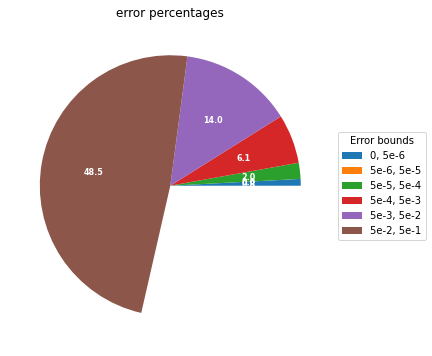

In [44]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6", 
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


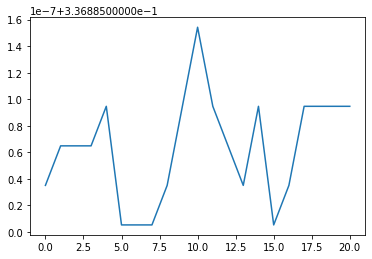

In [45]:
print(history2.history.keys())
# summarize history for accuracy
plt.plot(history2.history['loss'])
#plt.title('metric over epochs for predicted eigenvalues')
#plt.ylabel('mean absolute error')
#plt.xlabel('epoch')
#plt.legend(['MAE E train', 'MAE E test'], loc='upper left')
plt.show()

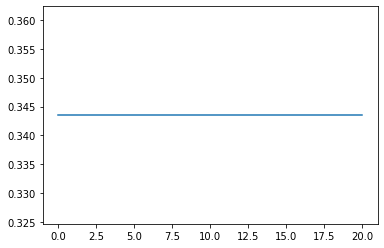

In [46]:
plt.plot(history2.history['val_loss'])
plt.show()

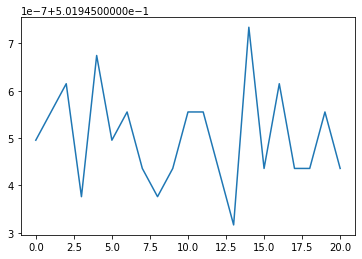

In [47]:
plt.plot(history2.history['mae'])
plt.show()

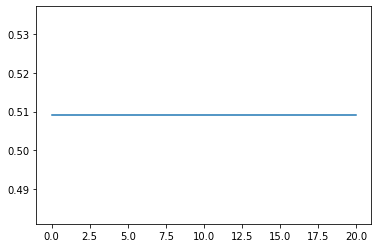

In [48]:
plt.plot(history2.history['val_mae'])
plt.show()

In [49]:
model2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_6 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
concatenate_2 (Concatenate)     (None, 2)            0           input_5[0][0]                    
                                                                 input_6[0][0]                    
__________________________________________________________________________________________________
dense_6 (Dense)                 (None, 50)           100         concatenate_2[0][0]        